# Chin Masking with MediaPipe
This notebook detects face landmarks and applies a smooth chin mask overlay using MediaPipe.

In [1]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

In [3]:
# Initialize MediaPipe Face Landmarker
print("Loading MediaPipe model...")
fm_model_path = 'face_landmarker.task'
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("MediaPipe ready!")

Loading MediaPipe model...
MediaPipe ready!


In [4]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True) # Bring to front
root.withdraw() # Hide the main tk window

file_path = filedialog.askopenfilename(
    title="Select an Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
else:
    print("No file selected.")
    file_path = None

Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/PiyushChunara/Downloads/new-front.jpg


In [5]:
import os
import urllib.request

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image provided. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        print("Downloading sample image...")
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    print(f"Image loaded: {w}x{h}")
else:
    print("Failed to load image.")

Image loaded: 320x425


In [6]:
# Detect face landmarks and apply chin overlay
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=image_rgb
)

detection_result = landmarker.detect(mp_image)
final_image = image_rgb.copy()

if detection_result.face_landmarks:
    landmarks = detection_result.face_landmarks[0]
    print("Face detected!")
    
    # Chin landmark indices
    CHIN_INDICES = [
        204, 83, 18, 313, 424, 431,
        395, 369, 396, 175, 171,
        140, 170, 211
    ]

    def get_smooth_polygon(indices):
        """Create smooth polygon using B-spline interpolation"""
        pts = np.array([
            [landmarks[idx].x * w, landmarks[idx].y * h]
            for idx in indices
        ])

        # Close polygon
        pts = np.vstack((pts, pts[0]))

        # Apply smooth curve interpolation
        tck, u = splprep(
            [pts[:, 0], pts[:, 1]],
            s=0,
            per=True
        )

        unew = np.linspace(0, 1, 100)
        out = splev(unew, tck)

        return np.int32(np.vstack((out[0], out[1])).T)

    chin_pts = get_smooth_polygon(CHIN_INDICES)

    # Apply chin overlay
    overlay = final_image.copy()
    CHIN_COLOR = (170, 185, 185)  # RGB pastel color

    cv2.fillPoly(overlay, [chin_pts], CHIN_COLOR)

    # Blend overlay with original image
    alpha = 0.65
    final_image = cv2.addWeighted(
        overlay,
        alpha,
        final_image,
        1 - alpha,
        0
    )
    print("Chin overlay applied!")

else:
    print("No face detected.")

Face detected!
Chin overlay applied!


c:\Users\PiyushChunara\AppData\Local\Programs\Python\Python310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


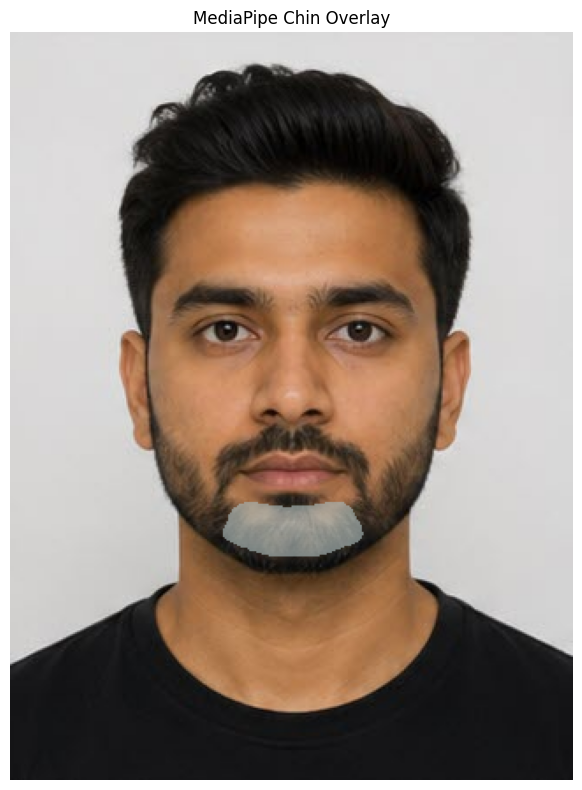

In [7]:
# Display result
plt.figure(figsize=(8, 8))
plt.imshow(final_image)
plt.axis("off")
plt.title("MediaPipe Chin Overlay")
plt.tight_layout()
plt.show()